In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")

print(df)


     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [2]:
df.shape

(891, 12)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [13]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [14]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [15]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [16]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


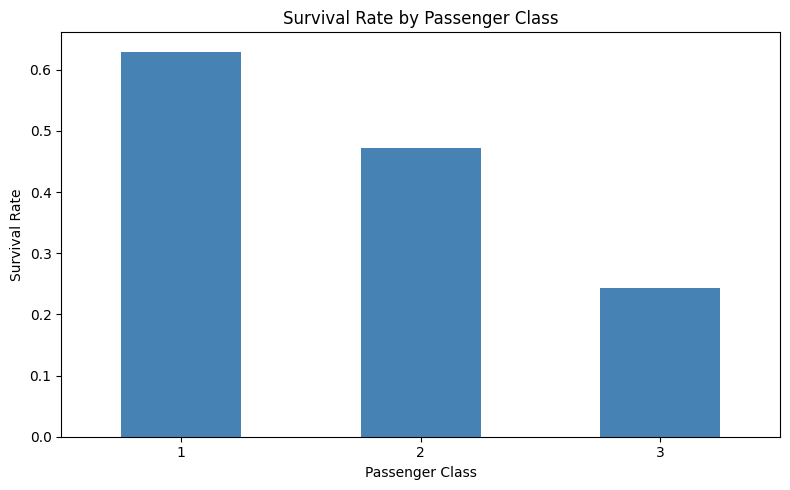

In [21]:
survival_by_class = df.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(8,5))
survival_by_class.plot(kind='bar', color='steelblue')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [23]:
df.groupby(['Pclass', 'Sex'])['Survived'].mean()

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

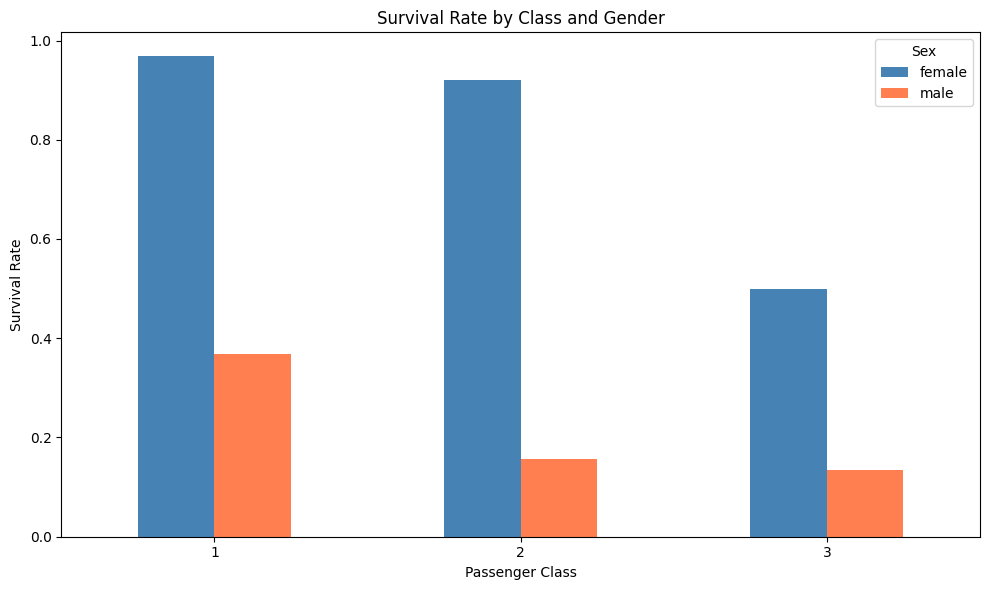

In [24]:
survival_pivot = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()

survival_pivot.plot(kind='bar', figsize=(10,6), color=['steelblue', 'coral'])
plt.title('Survival Rate by Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

In [27]:
df.groupby('Survived')['Age'].mean()

,Age
Survived,
0,30.626179
1,28.343690


In [28]:
print("""
TITANIC SURVIVAL ANALYSIS — KEY FINDINGS:

1. PASSENGER CLASS matters most after gender:
   - 1st class: 63% survival rate
   - 2nd class: 47% survival rate
   - 3rd class: 24% survival rate

2. GENDER was the biggest factor:
   - Female: 74% survival rate
   - Male: 19% survival rate

3. CLASS + GENDER combined tells the real story:
   - 1st class female: 97% survival (almost guaranteed)
   - 3rd class male: 14% survival (almost guaranteed death)

4. AGE had a small effect:
   - Survivors avg age: 28.3 years
   - Non-survivors avg age: 30.6 years

CONCLUSION:
Your best chance of surviving the Titanic was being
a young, wealthy woman in 1st class.
Your worst chance was being a poor man in 3rd class.
""")


TITANIC SURVIVAL ANALYSIS — KEY FINDINGS:

1. PASSENGER CLASS matters most after gender:
   - 1st class: 63% survival rate
   - 2nd class: 47% survival rate  
   - 3rd class: 24% survival rate

2. GENDER was the biggest factor:
   - Female: 74% survival rate
   - Male: 19% survival rate

3. CLASS + GENDER combined tells the real story:
   - 1st class female: 97% survival (almost guaranteed)
   - 3rd class male: 14% survival (almost guaranteed death)

4. AGE had a small effect:
   - Survivors avg age: 28.3 years
   - Non-survivors avg age: 30.6 years

CONCLUSION:
Your best chance of surviving the Titanic was being 
a young, wealthy woman in 1st class.
Your worst chance was being a poor man in 3rd class.

